# Surge Effective-Inertia Acceleration Sensitivity Check

本 notebook 以 surge 方向的 \(a=0.25\,\mathrm{m/s^2}\) corrected Javanmard 算例作为最终采用数据（mid），并将 \(a=0.10\)（low）和 \(a=0.50\)（high）作为加速度敏感性检验算例。

论文口径采用最终进入有效惯性矩阵的量：

$$
M_{x,\mathrm{eff}} = m - X_{\dot u} = m + (-X_{\dot u}).
$$

因此，加速度独立性检验的主判断指标是 \(M_{x,\mathrm{eff}}\) 相对变化率；\(-X_{\dot u}\) 仅作为计算链条和诊断中间量保留。


## 1. 常量、数据文件与取点规则

所有算例使用同一几何、同一流体密度和同一排水体积。提取规则保持一致：

- $F_{x,0}$：$1.8$--$2.0\,\mathrm{s}$低速平台均值；
- $F_{x,3}$：减速段内部再次满足 $V(t_3)=V_0$ 的单点力值；
- mid 是最终采用结果，low/high 只用于加速度敏感性检查。

本轮新增的 high 算例已经继续减速到 $V<V_0$，因此 $t_3=4.0\,\mathrm{s}$位于线性减速段内部。


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_rows", 40)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:.6g}")

BASE_DIR = Path(r"C:\AD_v2_stage1_analysis\mx_mz_calc")
DATA_DIR = BASE_DIR / "mx_data"
FIG_DIR = BASE_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

RHO = 997.561
V_DISPLACED = 0.002576
BODY_MASS_KG = 2.55
DISPLACED_MASS = RHO * V_DISPLACED

V0 = 1.0
F0_WINDOW = (1.8, 2.0)
BASELINE_KEY = "mid"

CASES = {
    "mid": {
        "label": r"$|a|=0.25\,\mathrm{m\,s^{-2}}$",
        "short_label": "a = 0.25",
        "role": "adopted result",
        "accel": 0.25,
        "t3_time": 5.0,
        "file": DATA_DIR / "mx_mid_accel_5.5s_1_00275_time_fx_inlet_velocity_20260619_005716.csv",
        "color": "#B4443F",
        "linestyle": "--",
    },
    "low": {
        "label": r"$|a|=0.10\,\mathrm{m\,s^{-2}}$",
        "short_label": "a = 0.10",
        "role": "low-acceleration check",
        "accel": 0.10,
        "t3_time": 5.0,
        "file": DATA_DIR / "mx_low_accel_5.5s_1_00275_time_fx_inlet_velocity_20260625_003043.csv",
        "color": "#777777",
        "linestyle": ":",
    },
    "high": {
        "label": r"$|a|=0.50\,\mathrm{m\,s^{-2}}$",
        "short_label": "a = 0.50",
        "role": "high-acceleration check",
        "accel": 0.50,
        "t3_time": 4.0,
        "file": DATA_DIR / "mx_high_accel_4s_1_00225_time_fx_inlet_velocity_robust_20260625_184514.csv",
        "color": "#2F5D8C",
        "linestyle": "-",
    },
}

for key, cfg in CASES.items():
    assert cfg["file"].exists(), f"Missing input file for {key}: {cfg['file']}"

print(f"DATA_DIR = {DATA_DIR}")
print(f"DISPLACED_MASS = {DISPLACED_MASS:.9f} kg")


DATA_DIR = C:\AD_v2_stage1_analysis\mx_mz_calc\mx_data
DISPLACED_MASS = 2.569717136 kg


## 2. 读取数据并检查速度曲线

这里检查每个算例的时间范围、\(t_3\) 取点和速度曲线。合格条件是：

1. CSV 包含 `time_s`, `fx_N`, `inlet_velocity_mps`；
2. \(t_3\) 处存在精确采样点；
3. \(V(t_3)=V_0=1.0\,\mathrm{m/s}\)；
4. \(t_3\) 后仍能看到 \(V<V_0\)，说明取点位于继续减速的过程内。


In [2]:
def load_case(case_key: str) -> pd.DataFrame:
    cfg = CASES[case_key]
    df = pd.read_csv(cfg["file"])
    required = {"time_s", "fx_N", "inlet_velocity_mps"}
    missing = required - set(df.columns)
    assert not missing, f"{cfg['file'].name} missing columns: {missing}"

    df = df.copy()
    for col in ["time_s", "fx_N", "inlet_velocity_mps"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["time_s", "fx_N", "inlet_velocity_mps"]).sort_values("time_s")
    df["case"] = case_key
    return df


def nearest_row(df: pd.DataFrame, target_time: float) -> pd.Series:
    idx = (df["time_s"] - target_time).abs().idxmin()
    return df.loc[idx]


case_data = {key: load_case(key) for key in CASES}

check_rows = []
for key, df in case_data.items():
    cfg = CASES[key]
    row = nearest_row(df, cfg["t3_time"])
    post_t3 = df.loc[df["time_s"] > cfg["t3_time"]]
    min_velocity_after_t3 = float(post_t3["inlet_velocity_mps"].min()) if len(post_t3) else np.nan
    check_rows.append(
        {
            "case": key,
            "role": cfg["role"],
            "acceleration_mps2": cfg["accel"],
            "n_rows": len(df),
            "time_min_s": float(df["time_s"].min()),
            "time_max_s": float(df["time_s"].max()),
            "t3_target_s": cfg["t3_time"],
            "t3_actual_s": float(row["time_s"]),
            "t3_velocity_mps": float(row["inlet_velocity_mps"]),
            "min_velocity_after_t3_mps": min_velocity_after_t3,
            "t3_Fx_N": float(row["fx_N"]),
        }
    )
    assert abs(float(row["time_s"]) - cfg["t3_time"]) < 1e-8, f"{key}: no exact t3 sample"
    assert abs(float(row["inlet_velocity_mps"]) - V0) < 1e-8, f"{key}: V(t3) != V0"
    assert min_velocity_after_t3 < V0, f"{key}: no continued deceleration after t3"

velocity_check = pd.DataFrame(check_rows)
display(velocity_check)


,case,role,acceleration_mps2,n_rows,time_min_s,time_max_s,t3_target_s,t3_actual_s,t3_velocity_mps,min_velocity_after_t3_mps,t3_Fx_N
0,mid,adopted result,0.25,275,0.02,5.5,5,5,1,0.875,0.105168
1,low,low-acceleration check,0.1,275,0.02,5.5,5,5,1,0.95,-0.41949
2,high,high-acceleration check,0.5,225,0.02,4.5,4,4,1,0.75,0.932222


## 3. 计算 apparent mass、\(-X_{\dot u}\) 与 \(M_{x,\mathrm{eff}}\)

Javanmard procedure two 先由同一速度 \(V_0\) 下的力差得到 apparent acceleration-related mass：

$$
M_{\mathrm{app},x}
=
\frac{\left|F_{x,3}-F_{x,0}\right|}{|a|}.
$$

再扣除排开水体惯性项得到水动力导数：

$$
-X_{\dot u}
=
M_{\mathrm{app},x}
-\rho V_d.
$$

本文主文使用的有效惯性项为：

$$
M_{x,\mathrm{eff}}
=
m-X_{\dot u}
=
m+(-X_{\dot u}).
$$


In [3]:
def compute_effective_inertia(case_key: str, df: pd.DataFrame) -> dict:
    cfg = CASES[case_key]
    f0_mask = (df["time_s"] >= F0_WINDOW[0]) & (df["time_s"] <= F0_WINDOW[1])
    f0_df = df.loc[f0_mask].copy()
    assert len(f0_df) > 0, f"{case_key}: no data in F0 window"

    f0 = float(f0_df["fx_N"].mean())
    f0_std = float(f0_df["fx_N"].std(ddof=0))
    f3_row = nearest_row(df, cfg["t3_time"])
    f3 = float(f3_row["fx_N"])
    delta_f = abs(f3 - f0)

    apparent_mass = delta_f / cfg["accel"]
    minus_xdotu = apparent_mass - DISPLACED_MASS
    xdotu = -minus_xdotu
    mx_eff = BODY_MASS_KG + minus_xdotu

    return {
        "case": case_key,
        "role": cfg["role"],
        "acceleration_mps2": cfg["accel"],
        "F0_window_s": f"{F0_WINDOW[0]}--{F0_WINDOW[1]}",
        "F0_samples": int(len(f0_df)),
        "F0_mean_N": f0,
        "F0_std_N": f0_std,
        "F3_time_s": float(f3_row["time_s"]),
        "F3_velocity_mps": float(f3_row["inlet_velocity_mps"]),
        "F3_N": f3,
        "delta_F_N": delta_f,
        "apparent_mass_kg": apparent_mass,
        "displaced_mass_kg": DISPLACED_MASS,
        "minus_X_dot_u_kg": minus_xdotu,
        "X_dot_u_kg": xdotu,
        "M_x_eff_kg": mx_eff,
    }


results = pd.DataFrame([compute_effective_inertia(key, df) for key, df in case_data.items()])
display(results)

results_path = DATA_DIR / "mx_accel_independence_results.csv"
results.to_csv(results_path, index=False, encoding="utf-8-sig")
print(f"Saved: {results_path}")


,case,role,acceleration_mps2,F0_window_s,F0_samples,F0_mean_N,F0_std_N,F3_time_s,F3_velocity_mps,F3_N,delta_F_N,apparent_mass_kg,displaced_mass_kg,minus_X_dot_u_kg,X_dot_u_kg,M_x_eff_kg
0,mid,adopted result,0.25,1.8--2.0,11,-0.79805,0.00119806,5,1,0.105168,0.903218,3.61287,2.56972,1.04316,-1.04316,3.59316
1,low,low-acceleration check,0.1,1.8--2.0,11,-0.79805,0.00119806,5,1,-0.41949,0.37856,3.7856,2.56972,1.21588,-1.21588,3.76588
2,high,high-acceleration check,0.5,1.8--2.0,11,-0.79805,0.00119806,4,1,0.932222,1.73027,3.46054,2.56972,0.890827,-0.890827,3.44083


Saved: C:\AD_v2_stage1_analysis\mx_mz_calc\mx_data\mx_accel_independence_results.csv


## 4. 以 mid 为基准的加速度敏感性

以最终采用的 mid 算例 \(a=0.25\,\mathrm{m/s^2}\) 为基准，分别计算 low 和 high 的相对差异。主指标为：

$$
\epsilon_{M_x}
=
\frac{
\left|M_{x,\mathrm{eff}}^{(i)}-M_{x,\mathrm{eff}}^{(\mathrm{mid})}\right|
}{
\left|M_{x,\mathrm{eff}}^{(\mathrm{mid})}\right|
}
\times 100\%.
$$

论文展示优先选择 \(\epsilon_{M_x}\) 最小的对比算例。


In [4]:
baseline = results.loc[results["case"] == BASELINE_KEY].iloc[0]

sensitivity_rows = []
for key in [k for k in CASES if k != BASELINE_KEY]:
    item = results.loc[results["case"] == key].iloc[0]

    delta_mx_eff = float(item["M_x_eff_kg"] - baseline["M_x_eff_kg"])
    epsilon_mx_eff = abs(delta_mx_eff) / abs(float(baseline["M_x_eff_kg"])) * 100.0

    delta_apparent = float(item["apparent_mass_kg"] - baseline["apparent_mass_kg"])
    epsilon_apparent = abs(delta_apparent) / abs(float(baseline["apparent_mass_kg"])) * 100.0

    delta_minus_xdotu = float(item["minus_X_dot_u_kg"] - baseline["minus_X_dot_u_kg"])
    epsilon_minus_xdotu = abs(delta_minus_xdotu) / abs(float(baseline["minus_X_dot_u_kg"])) * 100.0

    sensitivity_rows.append(
        {
            "case": key,
            "acceleration_mps2": float(item["acceleration_mps2"]),
            "M_x_eff_mid_kg": float(baseline["M_x_eff_kg"]),
            "M_x_eff_case_kg": float(item["M_x_eff_kg"]),
            "delta_M_x_eff_kg": delta_mx_eff,
            "epsilon_M_x_eff_percent": epsilon_mx_eff,
            "apparent_mass_mid_kg": float(baseline["apparent_mass_kg"]),
            "apparent_mass_case_kg": float(item["apparent_mass_kg"]),
            "epsilon_apparent_mass_percent": epsilon_apparent,
            "minus_X_dot_u_mid_kg": float(baseline["minus_X_dot_u_kg"]),
            "minus_X_dot_u_case_kg": float(item["minus_X_dot_u_kg"]),
            "epsilon_minus_X_dot_u_percent": epsilon_minus_xdotu,
        }
    )

sensitivity = pd.DataFrame(sensitivity_rows).sort_values("epsilon_M_x_eff_percent")
sensitivity["selected_for_paper_display"] = False
sensitivity.loc[sensitivity.index[0], "selected_for_paper_display"] = True
display(sensitivity)

best_case_key = str(sensitivity.iloc[0]["case"])
best_epsilon = float(sensitivity.iloc[0]["epsilon_M_x_eff_percent"])
print(f"Selected for paper display: {best_case_key} vs {BASELINE_KEY}, epsilon_Mx_eff = {best_epsilon:.3f}%")

sensitivity_path = DATA_DIR / "mx_accel_independence_sensitivity_summary.csv"
sensitivity.to_csv(sensitivity_path, index=False, encoding="utf-8-sig")
print(f"Saved: {sensitivity_path}")


,case,acceleration_mps2,M_x_eff_mid_kg,M_x_eff_case_kg,delta_M_x_eff_kg,epsilon_M_x_eff_percent,apparent_mass_mid_kg,apparent_mass_case_kg,epsilon_apparent_mass_percent,minus_X_dot_u_mid_kg,minus_X_dot_u_case_kg,epsilon_minus_X_dot_u_percent,selected_for_paper_display
1,high,0.5,3.59316,3.44083,-0.152329,4.23943,3.61287,3.46054,4.2163,1.04316,0.890827,14.6027,True
0,low,0.1,3.59316,3.76588,0.172723,4.80701,3.61287,3.7856,4.78078,1.04316,1.21588,16.5578,False


Selected for paper display: high vs mid, epsilon_Mx_eff = 4.239%
Saved: C:\AD_v2_stage1_analysis\mx_mz_calc\mx_data\mx_accel_independence_sensitivity_summary.csv


## 5. 论文候选图：mid 与最小差异算例

下图只绘制 mid 与自动选出的最小差异算例。当前数据下，最小差异算例应为 high，即 \(a=0.50\,\mathrm{m/s^2}\)。图包含两行：

- 上图：入口速度指令 \(V_{\mathrm{cmd}}\)；
- 下图：surge 方向力 \(F_x\)。


Saved: C:\AD_v2_stage1_analysis\mx_mz_calc\figures\mx_accel_independence_mid_vs_high_vcmd_fx.png
Saved: C:\AD_v2_stage1_analysis\mx_mz_calc\figures\mx_accel_independence_mid_vs_high_vcmd_fx.pdf


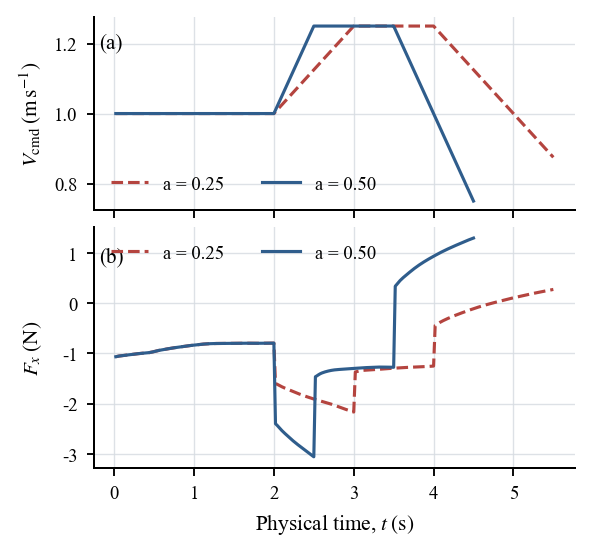

In [5]:
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "axes.unicode_minus": False,
        "figure.dpi": 180,
        "axes.labelsize": 8.5,
        "axes.titlesize": 9.0,
        "xtick.labelsize": 7.5,
        "ytick.labelsize": 7.5,
        "legend.fontsize": 7.5,
        "axes.linewidth": 0.8,
    }
)


def style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, color="#D7DCE2", linewidth=0.55, alpha=0.85)
    ax.tick_params(direction="out", length=3.0, width=0.75)


plot_keys = [BASELINE_KEY, best_case_key]

fig, (ax_v, ax_f) = plt.subplots(
    2,
    1,
    figsize=(3.45, 3.25),
    sharex=True,
    gridspec_kw={"height_ratios": [1.0, 1.25], "hspace": 0.08},
)

for key in plot_keys:
    df = case_data[key]
    cfg = CASES[key]
    ax_v.plot(
        df["time_s"],
        df["inlet_velocity_mps"],
        color=cfg["color"],
        linestyle=cfg["linestyle"],
        linewidth=1.25,
        label=cfg["short_label"],
    )
    ax_f.plot(
        df["time_s"],
        df["fx_N"],
        color=cfg["color"],
        linestyle=cfg["linestyle"],
        linewidth=1.25,
        label=cfg["short_label"],
    )

for ax in (ax_v, ax_f):
    style_axis(ax)

ax_v.set_ylabel(r"$V_{\mathrm{cmd}}\;(\mathrm{m\,s^{-1}})$")
ax_f.set_ylabel(r"$F_x\;(\mathrm{N})$")
ax_f.set_xlabel(r"Physical time, $t\;(\mathrm{s})$")

ax_v.text(0.01, 0.92, "(a)", transform=ax_v.transAxes, fontsize=8.5, va="top")
ax_f.text(0.01, 0.92, "(b)", transform=ax_f.transAxes, fontsize=8.5, va="top")

ax_v.legend(frameon=False, loc="best", ncol=2)
ax_f.legend(frameon=False, loc="best", ncol=2)

fig.align_ylabels([ax_v, ax_f])

figure_stem = f"mx_accel_independence_{BASELINE_KEY}_vs_{best_case_key}_vcmd_fx"
png_path = FIG_DIR / f"{figure_stem}.png"
pdf_path = FIG_DIR / f"{figure_stem}.pdf"
fig.savefig(png_path, dpi=600, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")
plt.show()


## 6. 结论

当前最终采用的 surge 惯性参数来自 mid 算例，即 \(a=0.25\,\mathrm{m/s^2}\)。low 和 high 只用于验证加速度幅值变化时，最终模型使用的有效惯性项 \(M_{x,\mathrm{eff}}\) 是否稳定。

本 notebook 自动选择 \(\epsilon_{M_x}\) 最小的算例作为论文中加速度独立性检验部分的展示对象。当前数据下，high 算例与 mid 的 \(M_{x,\mathrm{eff}}\) 差异最小，更适合放入论文主文展示；low 算例保留为补充诊断。


In [6]:
best_row = sensitivity.loc[sensitivity["selected_for_paper_display"]].iloc[0]

paper_recommendation = pd.DataFrame(
    [
        {
            "item": "adopted_case",
            "value": "mid, a = 0.25 m/s^2",
            "comment": "final surge effective-inertia result used by the model",
        },
        {
            "item": "paper_display_check",
            "value": f"{best_case_key}, a = {CASES[best_case_key]['accel']:.2f} m/s^2",
            "comment": "smallest effective-inertia difference from mid",
        },
        {
            "item": "epsilon_M_x_eff",
            "value": f"{best_row['epsilon_M_x_eff_percent']:.3f}%",
            "comment": "primary acceleration-sensitivity metric",
        },
        {
            "item": "epsilon_apparent_mass",
            "value": f"{best_row['epsilon_apparent_mass_percent']:.3f}%",
            "comment": "difference before subtracting displaced-water inertia",
        },
        {
            "item": "epsilon_minus_X_dot_u",
            "value": f"{best_row['epsilon_minus_X_dot_u_percent']:.3f}%",
            "comment": "diagnostic only; not the primary pass/fail metric",
        },
        {
            "item": "interpretation",
            "value": "acceptable effective-inertia robustness",
            "comment": "use mid vs high for the manuscript figure and discussion",
        },
    ]
)

display(paper_recommendation)


,item,value,comment
0,adopted_case,"mid, a = 0.25 m/s^2",final surge effective-inertia result used by t...
1,paper_display_check,"high, a = 0.50 m/s^2",smallest effective-inertia difference from mid
2,epsilon_M_x_eff,4.239%,primary acceleration-sensitivity metric
3,epsilon_apparent_mass,4.216%,difference before subtracting displaced-water ...
4,epsilon_minus_X_dot_u,14.603%,diagnostic only; not the primary pass/fail metric
5,interpretation,acceptable effective-inertia robustness,use mid vs high for the manuscript figure and ...
